In [2]:
# Install lib
!pip install torchaudio librosa seaborn -q

# lib
import torch
import torchaudio
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import random

# Seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cu128
GPU available: True
Using device: cuda


In [3]:
# data prep
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz
!mkdir -p /content/speech_commands
!tar -xzf speech_commands_v0.02.tar.gz -C /content/speech_commands
print("Done! Dataset downloaded.")

# commands available
import os
commands = [d for d in os.listdir('/content/speech_commands')
            if os.path.isdir(f'/content/speech_commands/{d}')
            and not d.startswith('_')]
print(f"Found {len(commands)} command folders:")
print(sorted(commands))

Done! Dataset downloaded.
Found 35 command folders:
['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [4]:
# chosen commands
COMMANDS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
DATA_DIR = Path('/content/speech_commands')
print("We will classify these commands:", COMMANDS)

We will classify these commands: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']


yes: 4044 samples
no: 3941 samples
up: 3723 samples
down: 3917 samples
left: 3801 samples
right: 3778 samples
on: 3845 samples
off: 3745 samples
stop: 3872 samples
go: 3880 samples


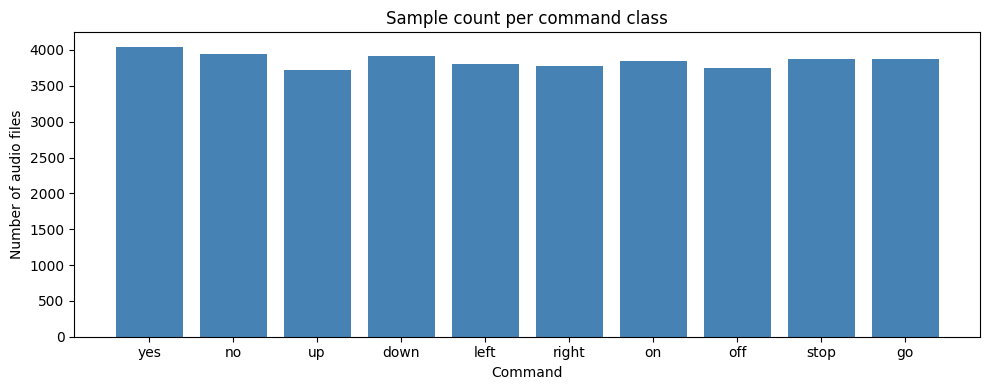

Class distribution looks balanced — good!


In [5]:
# sample check per command
counts = {}
for cmd in COMMANDS:
    files = list((DATA_DIR / cmd).glob('*.wav'))
    counts[cmd] = len(files)
    print(f"{cmd}: {len(files)} samples")

# Plot class distribution
plt.figure(figsize=(10, 4))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title('Sample count per command class')
plt.xlabel('Command')
plt.ylabel('Number of audio files')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()
print("Class distribution looks balanced — good!")

Sample rate: 16000 Hz
Duration: 1.00 seconds
Shape: torch.Size([1, 16000])


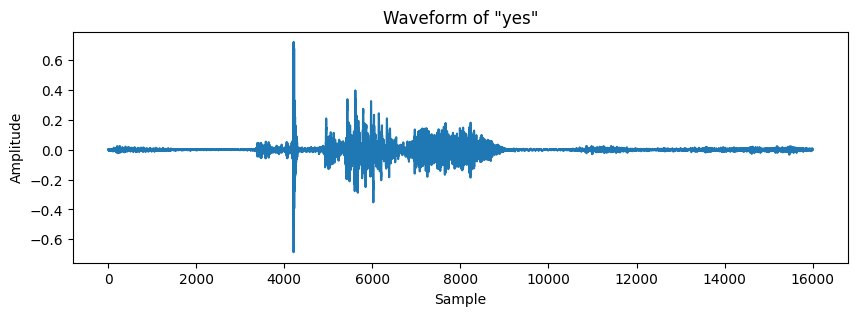

In [6]:
# sample for testing
import librosa
import librosa.display

sample_path = list((DATA_DIR / 'yes').glob('*.wav'))[0]
waveform, sample_rate = torchaudio.load(sample_path)
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {waveform.shape[1]/sample_rate:.2f} seconds")
print(f"Shape: {waveform.shape}")  # [channels, samples]

# Plot the waveform
plt.figure(figsize=(10, 3))
plt.plot(waveform[0].numpy())
plt.title('Waveform of "yes"')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()

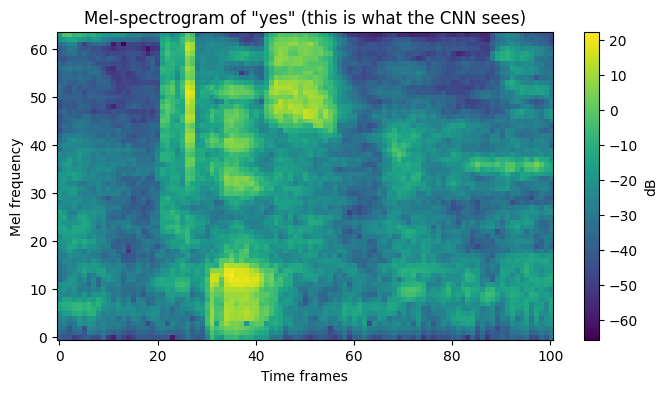

In [7]:
# CONVERSION TO MEL-SPECTOGRAM
mel_transform = T.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    hop_length=160,
    n_mels=64
)
db_transform = T.AmplitudeToDB()

mel_spec = mel_transform(waveform)
mel_db = db_transform(mel_spec)

plt.figure(figsize=(8, 4))
plt.imshow(mel_db[0].numpy(), origin='lower', aspect='auto', cmap='viridis')
plt.title('Mel-spectrogram of "yes" (this is what the CNN sees)')
plt.xlabel('Time frames')
plt.ylabel('Mel frequency')
plt.colorbar(label='dB')
plt.show()

# DATA PIPELINE

In [8]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class SpeechCommandDataset(Dataset):
    """Loads audio files and converts them to mel-spectrograms."""

    def __init__(self, file_paths, labels, transform=None, target_length=101):
        self.file_paths = file_paths
        self.labels = labels
        self.target_length = target_length  # standardize time dimension
        self.mel_transform = T.MelSpectrogram(
            sample_rate=16000, n_fft=400, hop_length=160, n_mels=64
        )
        self.db_transform = T.AmplitudeToDB()

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load audio
        waveform, sr = torchaudio.load(self.file_paths[idx])

        # Make sure it's mono (1 channel) and 16kHz
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)

        # Pad or trim to exactly 1 second (16000 samples)
        if waveform.shape[1] < 16000:
            waveform = torch.nn.functional.pad(waveform, (0, 16000 - waveform.shape[1]))
        else:
            waveform = waveform[:, :16000]

        # Convert to mel-spectrogram
        mel = self.mel_transform(waveform)
        mel = self.db_transform(mel)

        # Normalize to [0, 1]
        mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)

        return mel, self.labels[idx]

# Collect all file paths and labels
all_files = []
all_labels = []
label_to_idx = {cmd: i for i, cmd in enumerate(COMMANDS)}

for cmd in COMMANDS:
    files = list((DATA_DIR / cmd).glob('*.wav'))[:800]  # 800 per class for speed
    for f in files:
        all_files.append(str(f))
        all_labels.append(label_to_idx[cmd])

print(f"Total samples: {len(all_files)}")

# Split into train (70%), val (15%), test (15%) — stratified so classes are balanced
X_train, X_temp, y_train, y_temp = train_test_split(
    all_files, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Create datasets and dataloaders
train_dataset = SpeechCommandDataset(X_train, y_train)
val_dataset   = SpeechCommandDataset(X_val, y_val)
test_dataset  = SpeechCommandDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print("Data loaders ready!")

Total samples: 8000
Train: 5600, Val: 1200, Test: 1200
Data loaders ready!


#CNN MODEL

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SpectrogramCNN(nn.Module):
    """
    Input shape: [batch, 1, 64, 101] (mel-spectrogram image)
    """

    def __init__(self, num_classes=10):
        super(SpectrogramCNN, self).__init__()

        # Convolutional layers — learn visual patterns in the spectrogram
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 32 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 64 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 128 filters

        self.pool = nn.MaxPool2d(2, 2)   # halves spatial dimensions
        self.dropout = nn.Dropout(0.3)   # prevents overfitting
        self.bn1 = nn.BatchNorm2d(32)    # stabilizes training
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        # After 3 poolings: 64→32→16→8, 101→50→25→12
        self.fc1 = nn.Linear(128 * 8 * 12, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # → [b, 32, 32, 50]
        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # → [b, 64, 16, 25]
        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # → [b, 128, 8, 12]

        x = x.view(x.size(0), -1)       # flatten
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)                  # raw scores (logits)
        return x

model = SpectrogramCNN(num_classes=len(COMMANDS)).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SpectrogramCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=12288, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 3,241,674


#CNN TRAINING

In [ ]:
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

NUM_EPOCHS = 15
best_val_acc = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print("Starting training...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    running_loss, correct, total = 0, 0, 0

    for spectrograms, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        spectrograms, labels = spectrograms.to(device), labels.to(device)

        optimizer.zero_grad()           # clear old gradients
        outputs = model(spectrograms)   # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                 # compute gradients
        optimizer.step()                # update weights

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # --- Validation phase ---
    model.eval()
    val_loss_sum, val_correct, val_total = 0, 0, 0

    with torch.no_grad():  # no gradient computation needed for evaluation
        for spectrograms, labels in val_loader:
            spectrograms, labels = spectrograms.to(device), labels.to(device)
            outputs = model(spectrograms)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / len(val_loader)
    val_acc  = val_correct / val_total

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);     val_accs.append(val_acc)
    scheduler.step(val_loss)

    # Save the best model (early stopping logic)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.1f} minutes. Best val acc: {best_val_acc:.4f}")

Starting training...



Epoch 1/15:   0%|          | 0/88 [00:00<?, ?it/s]

In [ ]:
# learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train loss')
ax1.plot(val_losses, label='Val loss')
ax1.set_title('Loss curve'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(train_accs, label='Train acc')
ax2.plot(val_accs, label='Val acc')
ax2.set_title('Accuracy curve'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()

#CNN EVAL

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Load best model weights
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for spectrograms, labels in test_loader:
        spectrograms = spectrograms.to(device)
        outputs = model(spectrograms)
        probs = torch.softmax(outputs, dim=1)  # convert logits to probabilities
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
all_probs = np.array(all_probs)

print("=== Classification Report ===")
print(classification_report(all_true, all_preds, target_names=COMMANDS))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=COMMANDS, yticklabels=COMMANDS, cmap='Blues')
plt.title('Confusion matrix'); plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

#NLP

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

command_descriptions = {
    'yes':   'affirmative positive agreement confirmation',
    'no':    'negative denial refusal rejection',
    'up':    'upward direction increase raise higher',
    'down':  'downward direction decrease lower reduce',
    'left':  'leftward direction turn rotate left side',
    'right': 'rightward direction turn rotate right side',
    'on':    'activate enable start power on switch',
    'off':   'deactivate disable stop power off switch',
    'stop':  'halt cease pause end terminate command',
    'go':    'move proceed start continue forward action',
}

# NLP training
nlp_texts  = list(command_descriptions.values())
nlp_labels = list(command_descriptions.keys())

# Train NLP classifier (text → command category)
nlp_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=500, random_state=SEED))
])
nlp_pipeline.fit(nlp_texts, nlp_labels)

# Test
test_phrases = ['yes agree confirm', 'turn off disable', 'move forward go now']
for phrase in test_phrases:
    pred = nlp_pipeline.predict([phrase])[0]
    print(f"'{phrase}' → predicted command: '{pred}'")

print("\nNLP component working!")

#Reinforcement Learning Threshold-Tuning Agent

In [ ]:
class ThresholdTuningAgent:
    """
    State:  current threshold (discretized into bins)
    Action: raise threshold / lower threshold / keep same
    Reward: based on cost of false accepts and false rejects

    A false accept  = accepting a wrong prediction (dangerous, high cost)
    A false reject  = rejecting a correct prediction (annoying, low cost)
    """

    def __init__(self, n_bins=10, lr=0.1, gamma=0.9, epsilon=0.3):
        self.n_bins    = n_bins
        self.lr        = lr       # learning rate
        self.gamma     = gamma    # discount factor
        self.epsilon   = epsilon  # exploration rate (epsilon-greedy)
        self.n_actions = 3        # 0=lower, 1=keep, 2=raise
        # Q-table: rows = threshold states, cols = actions
        self.q_table   = np.zeros((n_bins, self.n_actions))
        self.threshold_values = np.linspace(0.1, 0.99, n_bins)
        self.current_bin = n_bins // 2

    @property
    def threshold(self):
        return self.threshold_values[self.current_bin]

    def get_action(self):
        """Epsilon-greedy: explore randomly or exploit best known action."""
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        return int(np.argmax(self.q_table[self.current_bin]))

    def apply_action(self, action):
        """Move threshold up, down, or stay."""
        if action == 0:
            self.current_bin = max(0, self.current_bin - 1)
        elif action == 2:
            self.current_bin = min(self.n_bins - 1, self.current_bin + 1)

    def compute_reward(self, probs, true_labels,
                       false_accept_cost=5.0, false_reject_cost=1.0):
        """
        Compute reward for current threshold.
        High confidence = accept prediction.
        Low confidence = reject (say 'uncertain').
        """
        max_probs  = probs.max(axis=1)      # highest class probability
        pred_class = probs.argmax(axis=1)   # predicted class

        accepted = max_probs >= self.threshold
        correct  = (pred_class == true_labels)

        false_accepts  = np.sum( accepted & ~correct)  # accepted but wrong
        false_rejects  = np.sum(~accepted &  correct)  # rejected but right
        true_accepts   = np.sum( accepted &  correct)  # accepted and right

        reward = (true_accepts
                  - false_accept_cost  * false_accepts
                  - false_reject_cost  * false_rejects)
        return float(reward)

    def update(self, state, action, reward, next_state):
        """Q-learning update rule."""
        best_next = np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next
        self.q_table[state, action] += self.lr * (td_target - self.q_table[state, action])

# RL Agent Training
agent = ThresholdTuningAgent(n_bins=10, epsilon=0.3)
N_EPISODES = 200
rewards_per_episode = []

print("Training RL agent...\n")

for episode in range(N_EPISODES):
    # Batch sampling
    idx = np.random.choice(len(all_probs), size=200, replace=False)
    batch_probs  = all_probs[idx]
    batch_labels = all_true[idx]

    state = agent.current_bin
    total_reward = 0

    for _ in range(10):  # 10 steps per episode
        action = agent.get_action()
        agent.apply_action(action)
        reward     = agent.compute_reward(batch_probs, batch_labels)
        next_state = agent.current_bin
        agent.update(state, action, reward, next_state)
        state       = next_state
        total_reward += reward

    # Decay epsilon (explore less over time)
    agent.epsilon = max(0.05, agent.epsilon * 0.995)
    rewards_per_episode.append(total_reward)

    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1} | Avg reward: {np.mean(rewards_per_episode[-50:]):.2f} "
              f"| Threshold: {agent.threshold:.3f} | Epsilon: {agent.epsilon:.3f}")

print(f"\nFinal learned threshold: {agent.threshold:.3f}")

In [ ]:
# Plot RL learning curve (required by specs)
plt.figure(figsize=(10, 4))
window = 20
smoothed = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')
plt.plot(rewards_per_episode, alpha=0.3, color='steelblue', label='Raw reward')
plt.plot(smoothed, color='steelblue', linewidth=2, label=f'{window}-episode moving avg')
plt.title('RL agent learning curve')
plt.xlabel('Episode'); plt.ylabel('Total reward')
plt.legend(); plt.tight_layout()
plt.savefig('rl_learning_curve.png')
plt.show()

#ABLATIONS and ERROR ANALYSIS

In [ ]:
# No data augmentation vs. with augmentation
# with time-masking and frequency-masking (SpecAugment)

class AugmentedSpeechDataset(SpeechCommandDataset):
    def __init__(self, *args, augment=False, **kwargs):
        super().__init__(*args, **kwargs)
        self.augment = augment
        self.time_mask  = T.TimeMasking(time_mask_param=20)
        self.freq_mask  = T.FrequencyMasking(freq_mask_param=10)

    def __getitem__(self, idx):
        mel, label = super().__getitem__(idx)
        if self.augment and random.random() > 0.5:
            mel = self.time_mask(mel)
            mel = self.freq_mask(mel)
        return mel, label

# Train a fresh model WITH augmentation
model_aug = SpectrogramCNN(num_classes=len(COMMANDS)).to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)

train_aug = AugmentedSpeechDataset(X_train, y_train, augment=True)
loader_aug = DataLoader(train_aug, batch_size=64, shuffle=True, num_workers=2)

print("Training augmented model (5 epochs for ablation comparison)...")
aug_val_accs = []
for epoch in range(5):
    model_aug.train()
    for specs, labels in loader_aug:
        specs, labels = specs.to(device), labels.to(device)
        optimizer_aug.zero_grad()
        loss = criterion(model_aug(specs), labels)
        loss.backward(); optimizer_aug.step()

    # Validate
    model_aug.eval(); correct = 0; total = 0
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            _, pred = model_aug(specs).max(1)
            correct += pred.eq(labels).sum().item(); total += labels.size(0)
    aug_val_accs.append(correct/total)
    print(f"Epoch {epoch+1}: Val acc = {correct/total:.4f}")

print(f"\nAblation 1 results (5 epochs):")
print(f"  Without augmentation: {val_accs[4]:.4f}")
print(f"  With augmentation:    {aug_val_accs[4]:.4f}")

In [ ]:
# Adam optimizer vs. SGD optimizer
model_sgd = SpectrogramCNN(num_classes=len(COMMANDS)).to(device)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

print("Training with SGD optimizer (5 epochs for ablation comparison)...")
sgd_val_accs = []
for epoch in range(5):
    model_sgd.train()
    for specs, labels in train_loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer_sgd.zero_grad()
        loss = criterion(model_sgd(specs), labels)
        loss.backward(); optimizer_sgd.step()

    model_sgd.eval(); correct = 0; total = 0
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            _, pred = model_sgd(specs).max(1)
            correct += pred.eq(labels).sum().item(); total += labels.size(0)
    sgd_val_accs.append(correct/total)
    print(f"Epoch {epoch+1}: Val acc = {correct/total:.4f}")

# Summary table
print("\n=== Ablation Results Summary ===")
print(f"Adam (baseline):        {val_accs[4]:.4f}")
print(f"Adam + SpecAugment:     {aug_val_accs[4]:.4f}")
print(f"SGD + momentum:         {sgd_val_accs[4]:.4f}")

#SLICE/ERROR ANALYSIS

In [ ]:
# Per-class accuracy breakdown (error analysis)
per_class_correct = {cmd: 0 for cmd in COMMANDS}
per_class_total   = {cmd: 0 for cmd in COMMANDS}

for pred, true in zip(all_preds, all_true):
    cmd = COMMANDS[true]
    per_class_total[cmd]   += 1
    if pred == true:
        per_class_correct[cmd] += 1

print("=== Per-class accuracy (error/slice analysis) ===")
for cmd in COMMANDS:
    acc = per_class_correct[cmd] / per_class_total[cmd]
    bar = '█' * int(acc * 20)
    print(f"  {cmd:6s}: {acc:.3f} {bar}")

# Find the hardest classes (most confused with each other)
print("\n=== Most common errors ===")
for true_idx, cmd in enumerate(COMMANDS):
    mask = (all_true == true_idx) & (all_preds != true_idx)
    if mask.sum() > 0:
        wrong_preds = all_preds[mask]
        most_common_error = COMMANDS[np.bincount(wrong_preds).argmax()]
        print(f"  '{cmd}' most confused with '{most_common_error}'")